In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
from scipy.signal import periodogram, find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Annual components

In [3]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500 = z500.sel(time=slice('2000.1', '2017.12'))['z']

loc = (slice(None),) + (24, 5)
df = pd.Series(z500[loc].values, index=z500['time'].values)
print(f'Latitude: {z500[loc].lat.values}, Longitude: {z500[loc].lon.values}')
df.index.freq = 'h'

Latitude: 47.8125, Longitude: 28.125


In [12]:
def compute_periodogram(values):
    fs = 1.0  # Sampling frequency: 1 sample per hour
    freqs, power = periodogram(values, fs=fs)
    peaks, _ = find_peaks(power, height=100, distance=100) # peaks, properties
    peak_freqs = freqs[peaks]
    peak_periods = 1 / peak_freqs
    peak_periods = peak_periods[peak_periods < 24*365*2]
    peak_powers = power[peaks]
    peaks = [*zip(peak_periods, peak_powers)]
    return peaks

In [13]:
peaks = compute_periodogram(df.values)
peaks[:10]

[(8766.666666666666, 199429200000.0),
 (744.3396226415094, 1203097900.0),
 (475.30120481927713, 627692540.0),
 (364.43418013856814, 335190850.0),
 (284.3243243243243, 230755860.0),
 (239.453717754173, 258315340.0),
 (203.61290322580646, 211206400.0),
 (178.50678733031674, 246063820.0),
 (160.2030456852792, 157409260.0),
 (145.1701931922723, 62205172.0)]

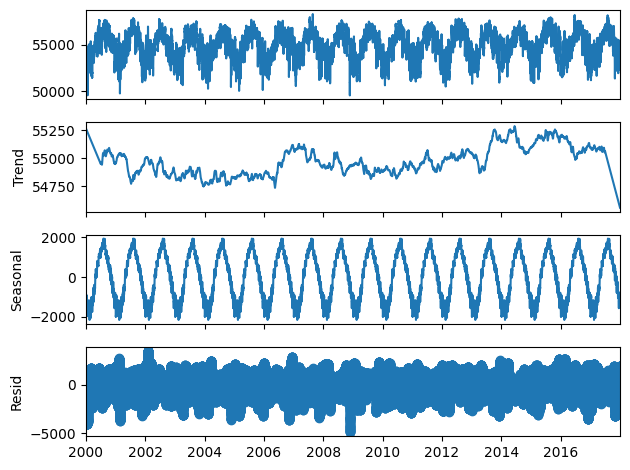

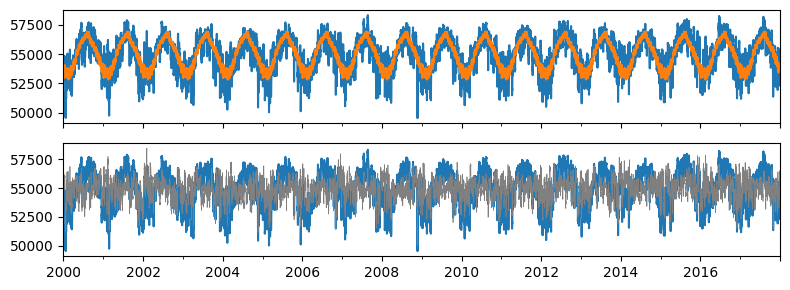

In [ ]:
res = seasonal_decompose(df, model='additive', extrapolate_trend=True, period=8767)
trend = res.trend
seasonal = res.seasonal
residual = df - seasonal

res.plot()

# Ignore the trend, just plot the seasonal component and the (original - seasonal) residual
fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
df.plot(ax=axs[0])
(df.mean() + seasonal).plot(ax=axs[0])
df.plot(ax=axs[1])
(residual).plot(lw=.5, color='gray', ax=axs[1], label='Residuals')
fig.tight_layout()

In [47]:
df.std(), residual.std()

(1456.1718, 902.8089211873661)

Lags: 14


<Axes: >

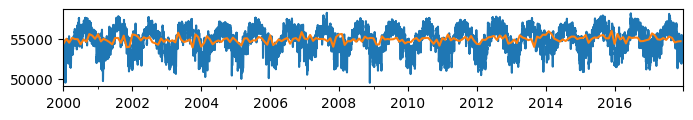

In [ ]:
residual_downsampled = residual.resample('ME').mean()
lags = int(np.sqrt(len(residual_downsampled)))
print('Lags:', lags)

      lb_stat  lb_pvalue
14  13.559362   0.483028


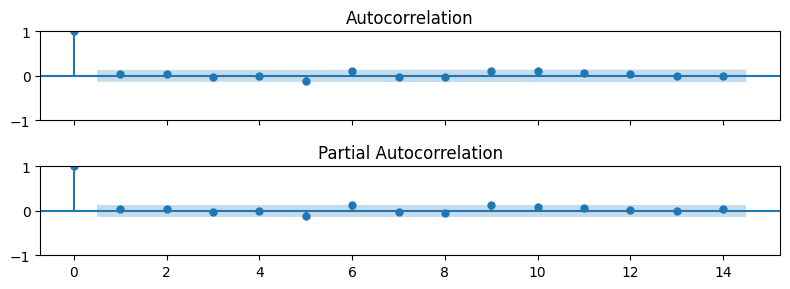

In [44]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

fig, ax = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
plot_acf(residual_downsampled, lags=lags, ax=ax[0])
plot_pacf(residual_downsampled, lags=lags, ax=ax[1])
fig.tight_layout()

# Ljung-Box test
ljung_box = acorr_ljungbox(residual_downsampled, lags=[lags], return_df=True)
print(ljung_box)

array([[6.86087000e+03, 1.63297774e+09],
       [7.44340000e+02, 1.20259811e+09],
       [4.75300000e+02, 6.26593109e+08],
       [3.64430000e+02, 3.36421837e+08],
       [2.84320000e+02, 2.31200700e+08]])

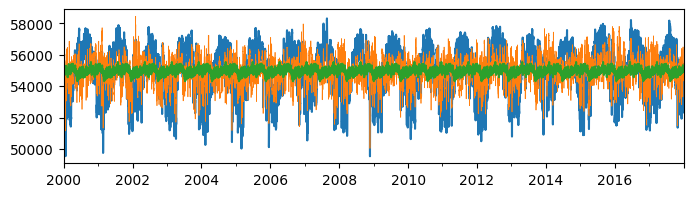

In [60]:
peaks_1 = compute_periodogram(residual.values)
res_1 = seasonal_decompose(residual, model='additive', extrapolate_trend=True, period=int(peaks_1[0][0]))
trend_1 = res_1.trend
seasonal_1 = res_1.seasonal

plt.figure(figsize=(8,2))
df.plot()
residual.plot(lw=.5)
(seasonal_1 + df.mean()).plot()
np.around(peaks_1[:5], 2)

# Single year

Peak at period = 878.40   hrs, power = 8.72735e+08
Peak at period = 64.12    hrs, power = 2.06775e+07
Peak at period = 35.42    hrs, power = 1.01527e+06
Peak at period = 24.00    hrs, power = 1.04742e+07
Peak at period = 18.53    hrs, power = 1.78789e+05
Peak at period = 14.81    hrs, power = 1.48937e+05
Peak at period = 12.00    hrs, power = 1.91412e+06
Peak at period = 10.48    hrs, power = 3.59790e+04
Peak at period = 9.12     hrs, power = 1.78315e+04
Peak at period = 7.99     hrs, power = 5.39215e+04
Peak at period = 7.08     hrs, power = 9.35413e+03


Text(0, 0.5, 'Residual')

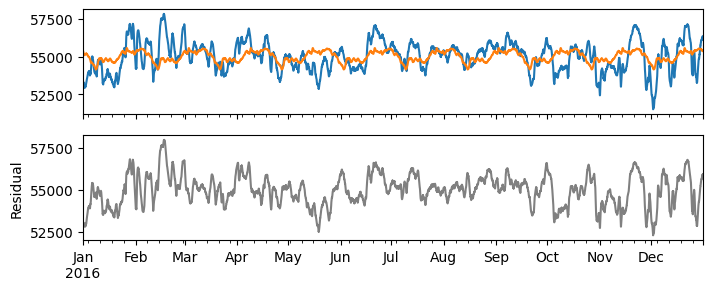

In [134]:
# Look at a single year
residual_year = residual.loc['2016':'2016']
freqs, power = periodogram(residual_year.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=100)
peak_freqs = freqs[peaks]
peak_periods = 1 / peak_freqs
peak_periods = peak_periods[peak_periods < 24*365*2]
peak_powers = power[peaks]
for i, (f, p) in enumerate(zip(peak_freqs, peak_powers)):
    if i > 10: break
    print(f"Peak at period = {1/f:<8.2f} hrs, power = {p:.5e}")

res = seasonal_decompose(residual_year, model='additive', extrapolate_trend=True, period=878)
trend = res.trend
seasonal = res.seasonal

fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
ax, ax1 = axs
residual_year.plot(ax=ax)
(residual_year.mean() + seasonal).plot(ax=ax)
(residual_year - seasonal).plot(ax=ax1, color='gray')

ax1.set_ylabel('Residual')

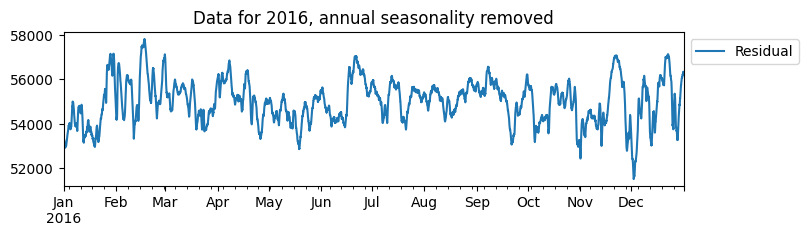

In [167]:
fig, ax = plt.subplots(figsize=(8, 2))
# df.loc['2016':'2016'].plot(label='Original')
residual.loc['2016':'2016'].plot(ax=ax, color='C0', label='Residual')
ax.set_title('Data for 2016, annual seasonality removed')
ax.legend(bbox_to_anchor=(1, 1))

# Fitting a GP to the residuals
Not implemented yet, unclear if this is a good idea when residuals are quite large

In [153]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2000.1', '2011.12'))['z']
z500_test = z500.sel(time=slice('2012.1', '2017.12'))['z']

In [154]:
loc = (slice(None),) + (24, 5)
df_train = pd.Series(z500_train[loc].values, index=z500_train['time'].values)
print(f'Latitude: {z500_train[loc].lat.values}, Longitude: {z500_train[loc].lon.values}')
df_train.index.freq = 'h'

Latitude: 47.8125, Longitude: 28.125


Extract annual seasonality and subtract to get residuals

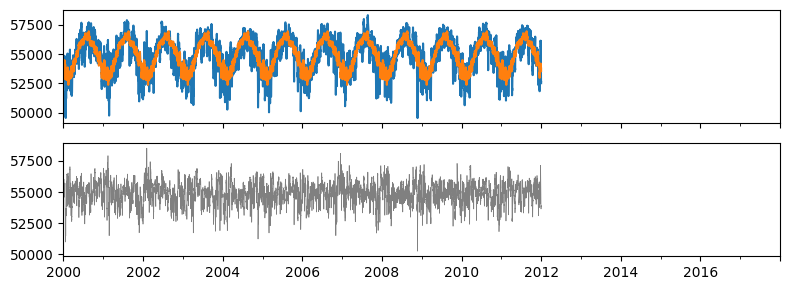

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(df_train, model='additive', extrapolate_trend=True, period=8767)
trend = res.trend
seasonal = res.seasonal
residual = df_train - seasonal

fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True)
df_train.plot(ax=axs[0])
(df_train.mean() + seasonal).plot(ax=axs[0])
(residual).plot(lw=.5, color='gray', ax=axs[1])

for ax in axs:
    ax.set_xlim(z500_train['time'].values[0], z500_test['time'].values[-1])

fig.tight_layout()